In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn.functional as F


In [2]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
char = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(char)}
stoi['.']=0 
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3
X , Y =[],[]
for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context),'---->',itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)


In [6]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [13]:
C = torch.randn((27,2))

In [14]:
C.shape

torch.Size([27, 2])

In [15]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [16]:
emb.view(32,6)

tensor([[-1.7433,  0.4771, -1.7433,  0.4771, -1.7433,  0.4771],
        [-1.7433,  0.4771, -1.7433,  0.4771, -0.4264, -0.7350],
        [-1.7433,  0.4771, -0.4264, -0.7350,  0.7041, -1.5772],
        [-0.4264, -0.7350,  0.7041, -1.5772,  0.7041, -1.5772],
        [ 0.7041, -1.5772,  0.7041, -1.5772,  0.5586, -0.7353],
        [-1.7433,  0.4771, -1.7433,  0.4771, -1.7433,  0.4771],
        [-1.7433,  0.4771, -1.7433,  0.4771,  0.7475, -0.4188],
        [-1.7433,  0.4771,  0.7475, -0.4188,  0.5868, -1.0557],
        [ 0.7475, -0.4188,  0.5868, -1.0557,  1.2729,  1.1189],
        [ 0.5868, -1.0557,  1.2729,  1.1189,  0.9728,  1.1089],
        [ 1.2729,  1.1189,  0.9728,  1.1089,  1.2729,  1.1189],
        [ 0.9728,  1.1089,  1.2729,  1.1189,  0.5586, -0.7353],
        [-1.7433,  0.4771, -1.7433,  0.4771, -1.7433,  0.4771],
        [-1.7433,  0.4771, -1.7433,  0.4771,  0.5586, -0.7353],
        [-1.7433,  0.4771,  0.5586, -0.7353,  0.9728,  1.1089],
        [ 0.5586, -0.7353,  0.9728,  1.1

In [17]:
W1 = torch.randn((6,100))
B1 = torch.randn(100)

In [19]:
h = torch.tanh(emb.view(-1,6) @ W1 +B1)

In [20]:
h

tensor([[ 1.0000, -0.9308,  0.2515,  ..., -0.9987,  0.8696,  0.9599],
        [ 1.0000,  0.4156,  0.7617,  ..., -0.9798,  0.9914,  0.9855],
        [ 0.9999,  0.9668, -0.6968,  ..., -0.9997,  0.7730,  0.9700],
        ...,
        [-0.1160,  0.9515, -0.7692,  ..., -0.9962,  0.0384, -0.5685],
        [-0.2464,  1.0000, -0.6778,  ..., -0.8037,  0.9993,  0.9749],
        [ 0.5783,  0.9999, -0.9998,  ..., -1.0000, -0.9996,  0.9963]])

In [21]:
h.shape

torch.Size([32, 100])

In [22]:
W2 = torch.randn((100,27))
B2 = torch.randn(27)

In [23]:
logits = h @ W2 + B2

In [55]:
counts = logits.exp()


In [29]:
prob = counts / counts.sum(1,keepdim=True)

In [31]:
prob.shape

torch.Size([32, 27])

In [32]:
prob[0].sum()

tensor(1.)

In [34]:
Y.shape

torch.Size([32])

In [35]:
loss = -(prob[torch.arange(32),Y]).log().mean()

In [36]:
loss

tensor(20.3733)

# --NOW with respect---

In [57]:
Xtr.shape,Ytr.shape

(torch.Size([182441, 3]), torch.Size([182441]))

In [118]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,15),generator=g,requires_grad=True)
W1 = torch.randn((45,300),generator=g,requires_grad=True)
B1 = torch.randn(300,generator=g,requires_grad=True)
W2 = torch.randn((300,27),generator=g,requires_grad=True)
B2 = torch.randn(27,generator=g,requires_grad=True)
parameters = [C,W1,B1,W2,B2]

In [119]:
sum(p.nelement() for p in parameters)



22332

In [120]:
# lre = torch.linspace(-3,0,1000)
# lrs = 10 ** lre
lri=[]
lossi=[]
stepi=[]

In [121]:

for i in range(200000):
    # mini batches
    ix = torch.randint(0,Xtr.shape[0],(32,))
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,45)@W1 +B1)
    logits = h @W2 +B2
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdim=True)
    # loss = - (prob[torch.arange(32),Y]).log().mean()
    # using cross entroppy
    loss = F.cross_entropy(logits,Ytr[ix])
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad=None
    loss.backward()
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01 
    for p in parameters:
        p.data += - lr*p.grad
        # lri.append(lre[i])
        stepi.append(i)
        lossi.append(loss.log10().item())
        
# print(loss.item())


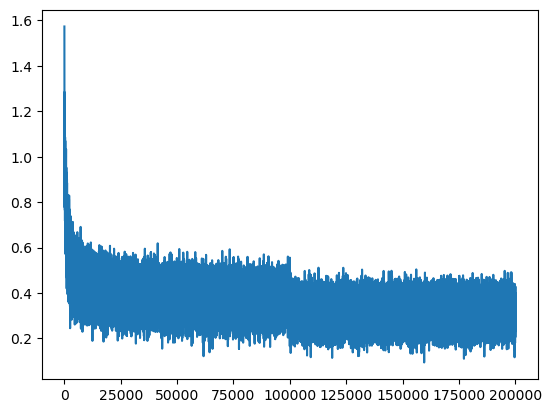

In [122]:
plt.plot(stepi,lossi)

In [123]:
emb=C[Xtr]
h =torch.tanh(emb.view(-1,45)@W1 +B1)
logits = h @ W2 +B2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.1057, grad_fn=<NllLossBackward0>)

In [124]:
emb=C[Xdev]
h =torch.tanh(emb.view(-1,45)@W1 +B1)
logits = h @ W2 +B2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.1773, grad_fn=<NllLossBackward0>)

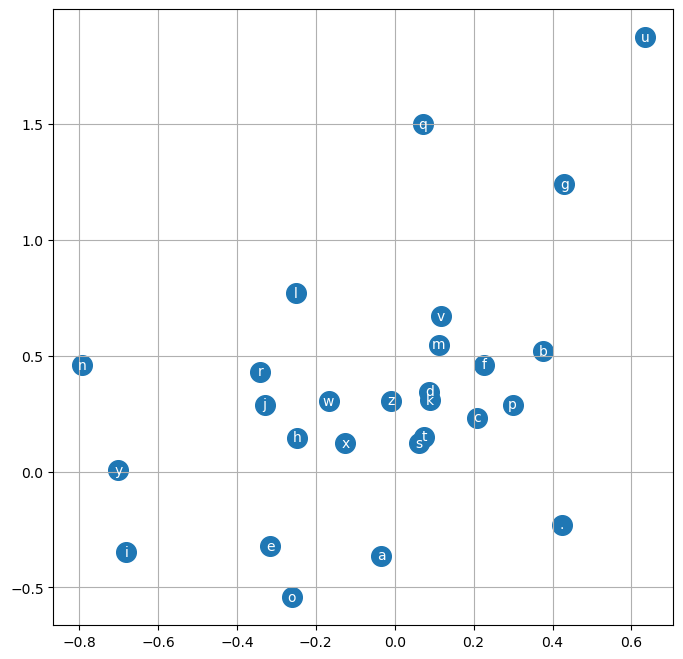

In [90]:
plt.figure(figsize = (8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha='center',va='center',color='white')
plt.grid('minor')


# -- dividing data into three set train,valid(dev),test

In [55]:
def data(words):
    block_size=3
    X =[]
    Y = []
    for w in words:
        context = [0] * block_size
        for ch in w+'.':
            ix =stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X ,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr,Ytr = data (words[:n1])
Xdev,Ydev = data(words[n1:n2])
Xte,Yte = data(words[n2:])
            

torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])


In [136]:
# sampling 2.1701 to beat

g =torch.Generator().manual_seed(2147483647+10)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 +B1)
        logits = h @ W2 + B2
        probs = F.softmax(logits,dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix ==0:
            break
    print(''.join(itos[i] for i in out))
        

carmah.
amillivia.
jari.
reaty.
skanden.
jazon.
naymeryncierenia.
ramara.
chrihvik.
leigh.
ham.
joce.
quinn.
shoine.
sia.
biro.
jerma.
jarynika.
jeriius.
brey.
